# Restaurant Branch Performance EDA — Day 13

## Objective
Perform Exploratory Data Analysis (EDA) on the Restaurant Branch Performance Dataset using Pandas and visualization techniques.

### Analysis areas
- Dataset structure and data quality
- Summary statistics and descriptive analysis
- Distribution of customers, revenue, profit, marketing spend, staff count, delivery time, and customer ratings
- Performance comparison across branches, regions, and store types
- Correlation analysis of numerical variables
- 5–8 data-driven observations and conclusions


## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Load the dataset
df = pd.read_csv("Day13_Restaurant_Branch_Performance_Dataset.csv")

df.head()


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,"4,977.25",172,135,375.75,"66,766.77","27,954.29","46,554.90","20,211.87",29.00,4.44,20.80,70.30,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,"8,998.30",285,263,530.64,"157,230.89","63,816.59","96,813.95","60,416.94",27.90,4.56,31.30,70.70,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,"10,034.97",306,264,534.97,"155,811.96","54,874.10","89,888.91","65,923.05",30.20,4.36,21.40,61.50,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,"5,095.84",198,167,370.05,"80,574.05","31,429.44","53,531.82","27,042.23",21.70,4.65,22.90,40.40,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,"6,681.82",148,116,364.62,"56,579.89","21,759.51","44,376.25","12,203.64",26.10,4.50,29.00,44.30,Clear,Combo Deal


## 2. Basic Dataset Exploration

In [2]:
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())


Dataset shape: (350, 22)
Number of rows: 350
Number of columns: 22

Column names:
['Record_ID', 'Date', 'Day', 'Month', 'Branch', 'Region', 'Store_Type', 'Staff_Count', 'Marketing_Spend', 'Customers', 'Orders', 'Average_Bill', 'Revenue', 'Food_Cost', 'Operating_Cost', 'Profit', 'Avg_Delivery_Min', 'Customer_Rating', 'Temperature_C', 'Humidity_Percent', 'Weather', 'Promotion']

Data types:
Record_ID            object
Date                 object
Day                  object
Month                object
Branch               object
Region               object
Store_Type           object
Staff_Count           int64
Marketing_Spend     float64
Customers             int64
Orders                int64
Average_Bill        float64
Revenue             float64
Food_Cost           float64
Operating_Cost      float64
Profit              float64
Avg_Delivery_Min    float64
Customer_Rating     float64
Temperature_C       float64
Humidity_Percent    float64
Weather              object
Promotion           

,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,"4,977.25",172,135,375.75,"66,766.77","27,954.29","46,554.90","20,211.87",29.00,4.44,20.80,70.30,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,"8,998.30",285,263,530.64,"157,230.89","63,816.59","96,813.95","60,416.94",27.90,4.56,31.30,70.70,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,"10,034.97",306,264,534.97,"155,811.96","54,874.10","89,888.91","65,923.05",30.20,4.36,21.40,61.50,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,"5,095.84",198,167,370.05,"80,574.05","31,429.44","53,531.82","27,042.23",21.70,4.65,22.90,40.40,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,"6,681.82",148,116,364.62,"56,579.89","21,759.51","44,376.25","12,203.64",26.10,4.50,29.00,44.30,Clear,Combo Deal



Last 5 rows:


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
345,ST0346,2026-02-08,Sunday,February,Mumbai,West,Express,10,"7,389.17",202,164,322.03,"56,852.25","18,863.88","43,733.92","13,118.33",27.20,4.63,28.90,64.60,Rain,NaN
346,ST0347,2026-06-05,Friday,June,Mumbai,West,Premium,12,"8,398.13",274,232,508.32,"138,198.35","50,914.04","75,370.62","62,827.73",35.40,4.32,22.70,57.90,Rain,NaN
347,ST0348,2026-03-13,Friday,March,Bengaluru,South,Standard,16,"2,876.93",196,183,322.37,"62,974.97","23,946.23","51,377.97","11,597.00",22.50,4.51,32.30,63.40,Clear,Combo Deal
348,ST0349,2026-03-10,Tuesday,March,Jaipur,North,Standard,9,"4,731.74",200,181,413.05,"78,451.05","26,050.73","47,400.29","31,050.76",28.30,4.51,24.70,58.60,Clear,Loyalty Offer
349,ST0350,2026-02-03,Tuesday,February,Pune,West,Standard,16,"7,004.28",225,204,381.10,"86,122.21","28,144.81","54,734.11","31,388.10",22.70,4.30,32.00,83.90,Clear,NaN


## 3. Missing Values and Duplicate Records

In [3]:
print("Missing values by column:")
display(df.isnull().sum().to_frame("Missing_Count"))

print("Duplicate rows:", df.duplicated().sum())

print("\nUnique values in categorical columns:")
categorical_cols = df.select_dtypes(include="object").columns
display(df[categorical_cols].nunique().to_frame("Unique_Count"))


Missing values by column:


,Missing_Count
Record_ID,0
Date,0
Day,0
Month,0
Branch,0
Region,0
Store_Type,0
Staff_Count,0
Marketing_Spend,0
Customers,0


Duplicate rows: 0

Unique values in categorical columns:


,Unique_Count
Record_ID,350
Date,161
Day,7
Month,6
Branch,8
Region,3
Store_Type,3
Weather,4
Promotion,3


**Data-quality finding:** All columns are complete except `Promotion`, which contains missing values. The missing promotion values are retained because they may represent days when no promotion was recorded/offered. There are no duplicate rows.

## 4. Summary Statistics

In [4]:
# Descriptive statistics for numerical variables
numeric_cols = df.select_dtypes(include="number").columns
display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Staff_Count,350.00,11.96,4.34,5.00,9.00,11.00,15.00,24.00
Marketing_Spend,350.00,"5,516.35","2,050.91",725.35,"4,339.73","5,393.37","6,748.50","11,784.96"
Customers,350.00,217.38,56.72,77.00,180.25,213.00,255.75,360.00
Orders,350.00,187.05,50.56,71.00,155.00,182.50,218.75,334.00
Average_Bill,350.00,388.91,82.49,180.00,337.31,383.49,441.76,623.28
Revenue,350.00,"86,831.80","36,644.45","20,540.76","61,261.72","79,766.88","102,976.18","194,018.92"
Food_Cost,350.00,"31,807.55","13,896.89","7,262.01","22,326.66","28,861.33","38,370.37","75,946.59"
Operating_Cost,350.00,"56,621.44","18,467.84","20,782.38","43,797.67","53,723.03","63,961.23","111,489.14"
Profit,350.00,"30,210.36","19,508.59","-6,924.68","16,915.49","26,873.87","39,823.74","89,096.19"
Avg_Delivery_Min,350.00,26.10,4.39,13.90,22.80,26.10,29.08,38.30


In [5]:
# Descriptive statistics for categorical variables
categorical_cols = df.select_dtypes(include="object").columns
display(df[categorical_cols].describe().T)


,count,unique,top,freq
Record_ID,350,350,ST0350,1
Date,350,161,2026-05-21,5
Day,350,7,Tuesday,56
Month,350,6,February,65
Branch,350,8,Srinagar,52
Region,350,3,South,137
Store_Type,350,3,Standard,196
Weather,350,4,Clear,189
Promotion,166,3,Weekend Offer,74


## 5. Important Numerical Variables

In [6]:
important_cols = [
    "Customers", "Revenue", "Profit", "Marketing_Spend",
    "Staff_Count", "Avg_Delivery_Min", "Customer_Rating"
]

summary = df[important_cols].agg(["mean", "median", "min", "max", "std"]).T
display(summary)


,mean,median,min,max,std
Customers,217.38,213.00,77.00,360.00,56.72
Revenue,"86,831.80","79,766.88","20,540.76","194,018.92","36,644.45"
Profit,"30,210.36","26,873.87","-6,924.68","89,096.19","19,508.59"
Marketing_Spend,"5,516.35","5,393.37",725.35,"11,784.96","2,050.91"
Staff_Count,11.96,11.00,5.00,24.00,4.34
Avg_Delivery_Min,26.10,26.10,13.90,38.30,4.39
Customer_Rating,4.47,4.47,3.76,4.96,0.20


## 6. Distribution Analysis

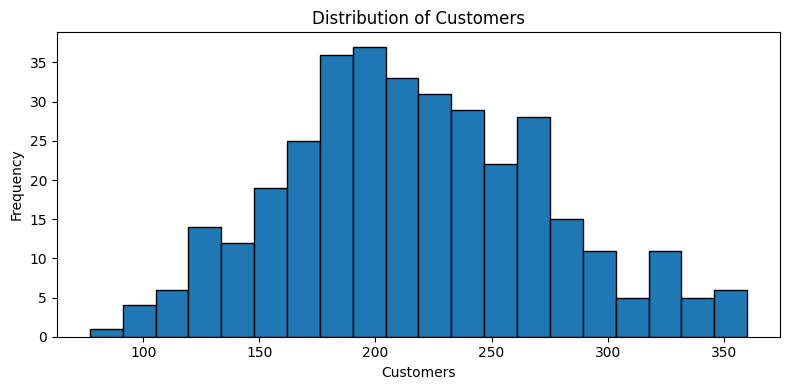

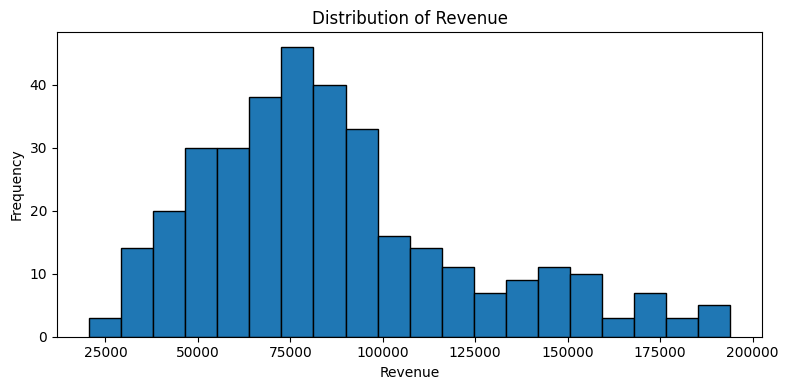

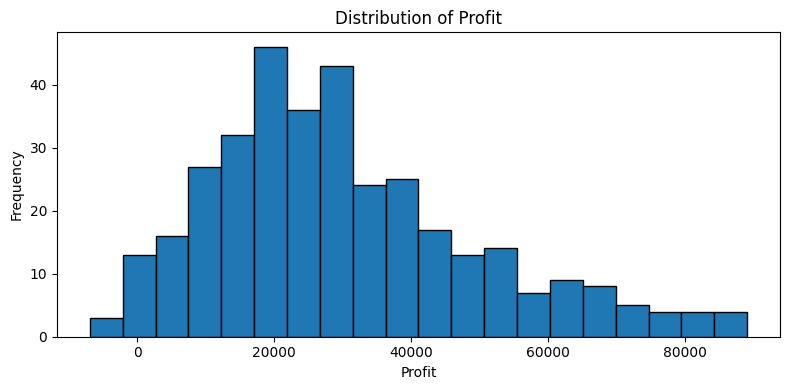

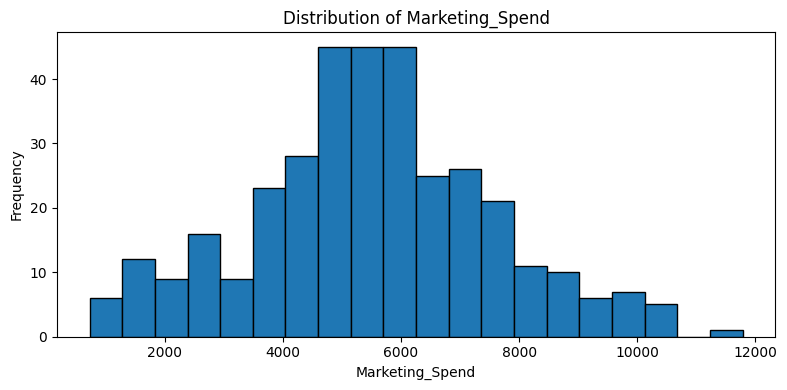

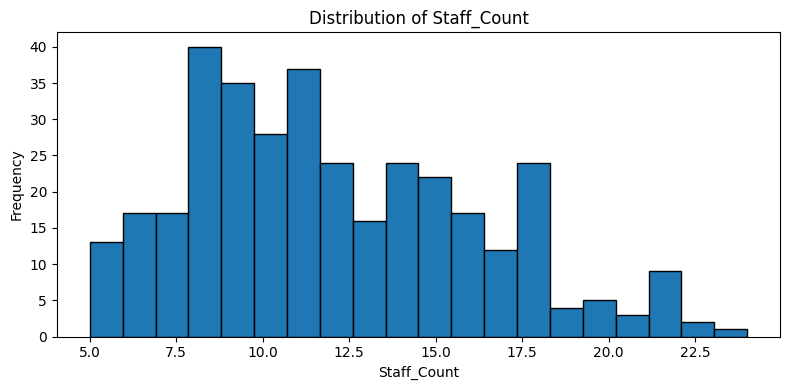

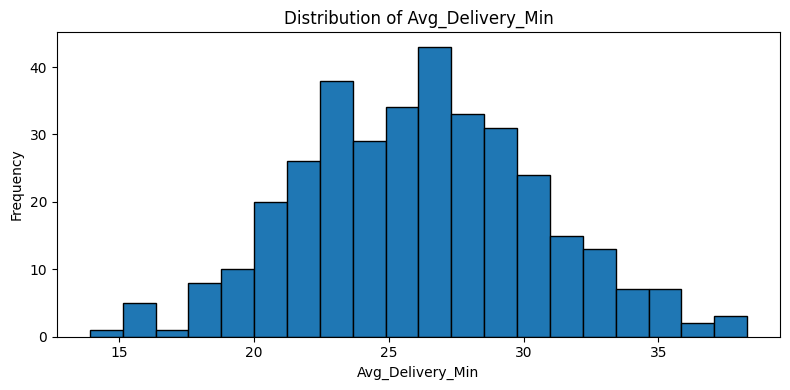

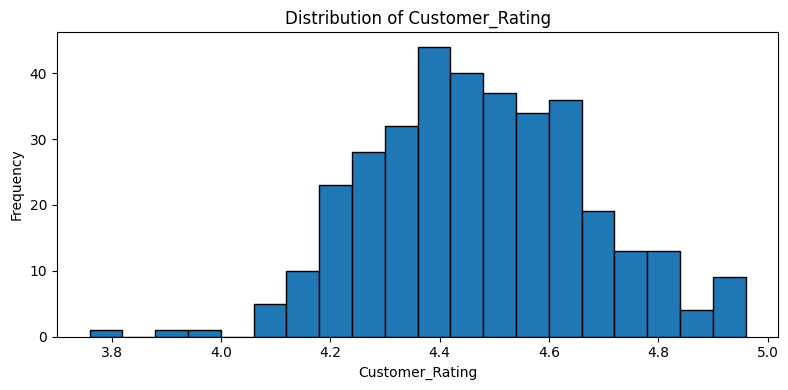

In [7]:
# Histograms for important numerical variables
for col in important_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=20, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


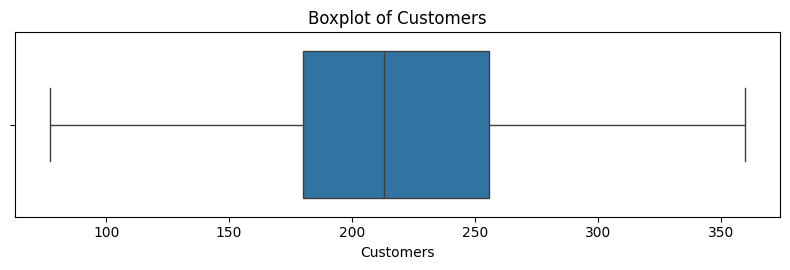

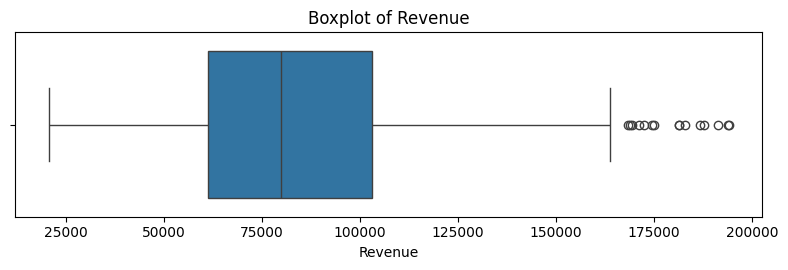

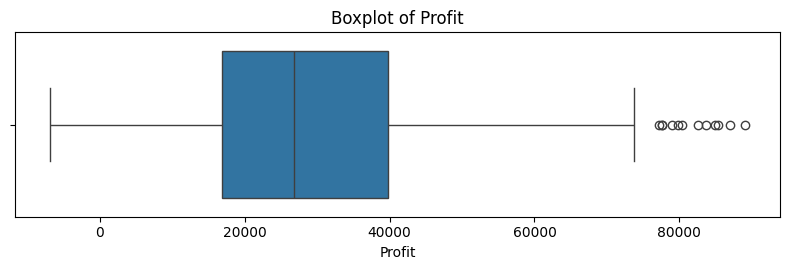

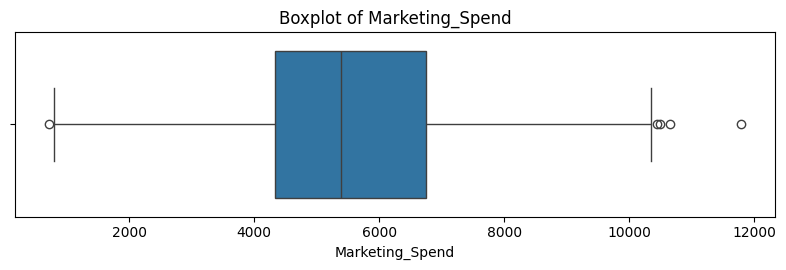

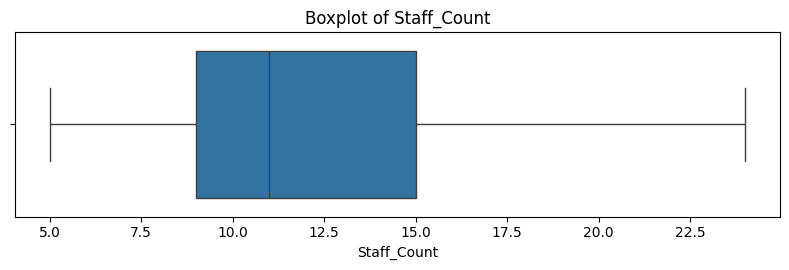

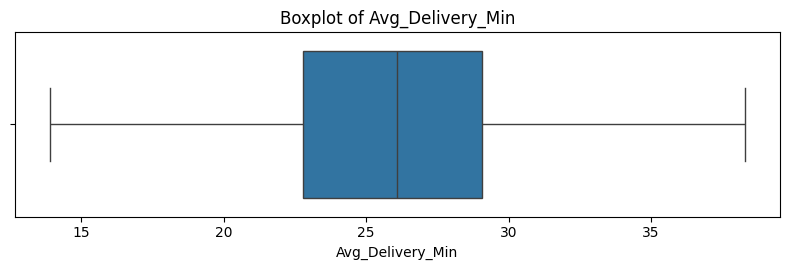

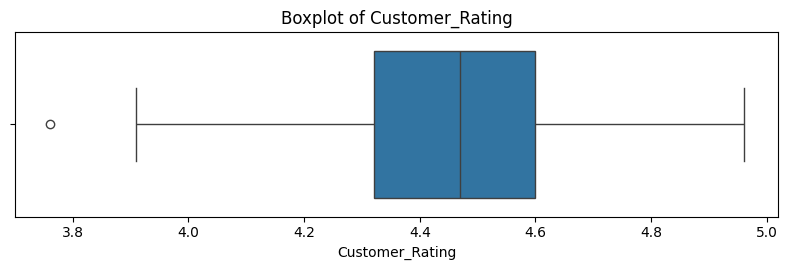

In [8]:
# Boxplots to inspect spread and possible outliers
for col in important_cols:
    plt.figure(figsize=(8, 2.8))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


## 7. Branch-wise Performance

In [9]:
branch_performance = df.groupby("Branch").agg(
    Records=("Record_ID", "count"),
    Customers=("Customers", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Avg_Rating=("Customer_Rating", "mean"),
    Avg_Delivery=("Avg_Delivery_Min", "mean")
).sort_values("Profit", ascending=False)

display(branch_performance)


,Records,Customers,Revenue,Profit,Avg_Rating,Avg_Delivery
Branch,,,,,,
Srinagar,52,11166,"4,510,816.59","1,575,751.62",4.48,25.97
Bengaluru,46,10465,"4,173,677.46","1,466,982.08",4.47,26.56
Jaipur,48,10717,"4,163,815.60","1,462,545.76",4.47,26.58
Kochi,48,10035,"4,107,581.66","1,387,297.74",4.42,25.84
Hyderabad,43,9494,"3,818,610.68","1,350,328.01",4.47,25.52
Mumbai,44,9406,"3,554,286.95","1,169,563.49",4.44,26.86
Pune,37,7952,"3,259,977.12","1,156,826.16",4.54,25.53
Delhi,32,6847,"2,802,363.82","1,004,329.45",4.49,25.69


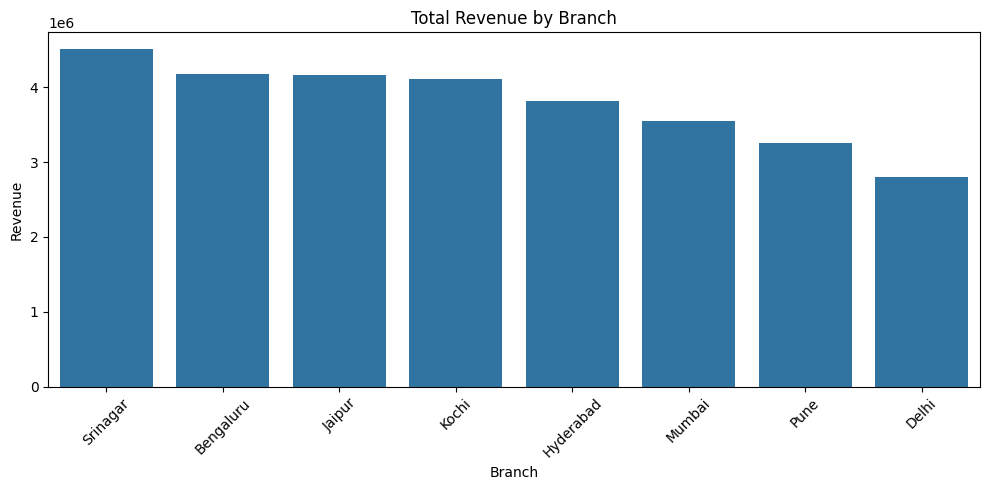

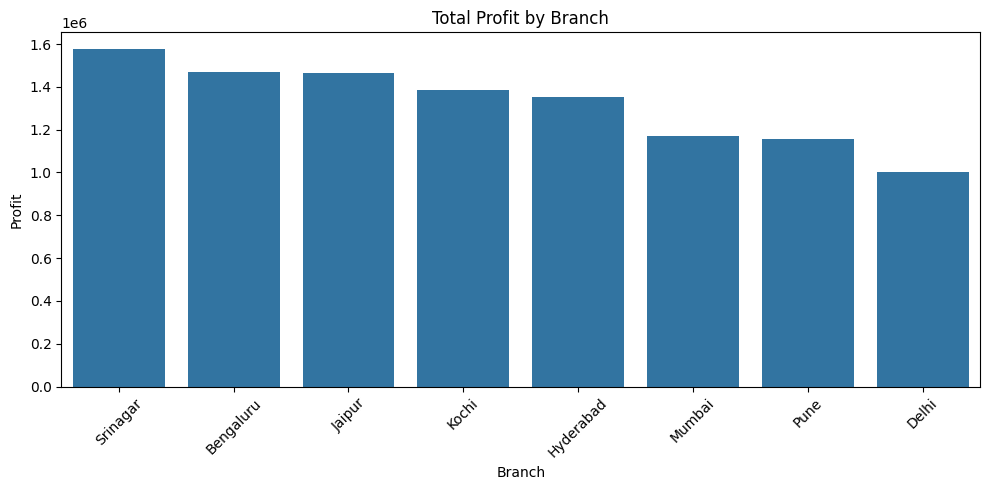

In [10]:
# Branch revenue comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=branch_performance.reset_index(), x="Branch", y="Revenue")
plt.title("Total Revenue by Branch")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Branch profit comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=branch_performance.reset_index(), x="Branch", y="Profit")
plt.title("Total Profit by Branch")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Region-wise Performance

In [11]:
region_performance = df.groupby("Region").agg(
    Records=("Record_ID", "count"),
    Customers=("Customers", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Avg_Rating=("Customer_Rating", "mean")
).sort_values("Profit", ascending=False)

display(region_performance)


,Records,Customers,Revenue,Profit,Avg_Rating
Region,,,,,
South,137,29994,"12,099,869.80","4,204,607.83",4.45
North,132,28730,"11,476,996.01","4,042,626.83",4.48
West,81,17358,"6,814,264.07","2,326,389.65",4.49


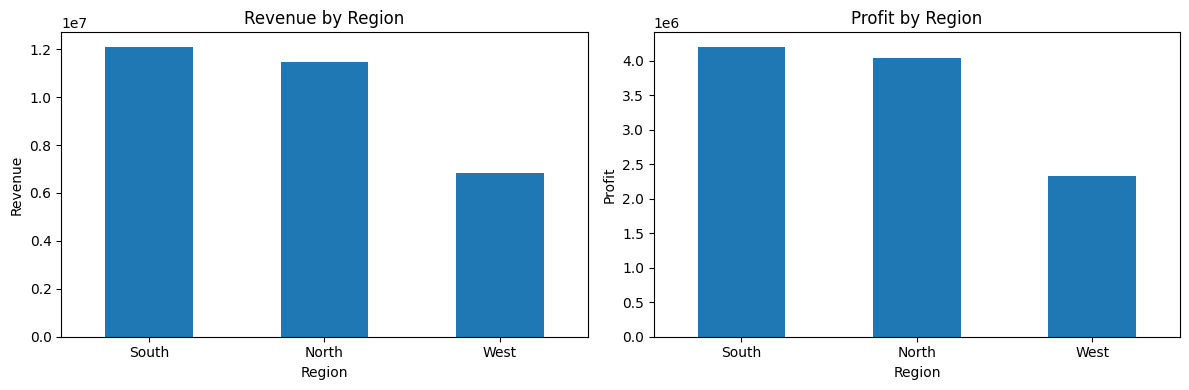

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

region_performance["Revenue"].plot(kind="bar", ax=axes[0], title="Revenue by Region")
axes[0].set_ylabel("Revenue")
axes[0].tick_params(axis="x", rotation=0)

region_performance["Profit"].plot(kind="bar", ax=axes[1], title="Profit by Region")
axes[1].set_ylabel("Profit")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 9. Store Type Performance

In [13]:
store_performance = df.groupby("Store_Type").agg(
    Records=("Record_ID", "count"),
    Customers=("Customers", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Avg_Rating=("Customer_Rating", "mean"),
    Avg_Delivery=("Avg_Delivery_Min", "mean")
).sort_values("Profit", ascending=False)

display(store_performance)


,Records,Customers,Revenue,Profit,Avg_Rating,Avg_Delivery
Store_Type,,,,,,
Standard,196,44096,"17,104,658.78","6,003,634.00",4.47,25.98
Premium,52,15534,"7,949,100.29","3,270,292.24",4.46,26.40
Express,102,16452,"5,337,370.81","1,299,698.07",4.46,26.17


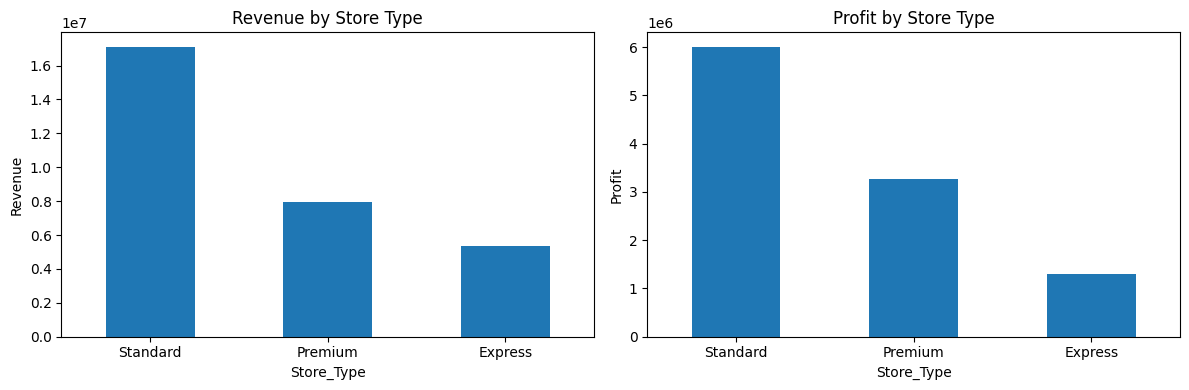

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

store_performance["Revenue"].plot(kind="bar", ax=axes[0], title="Revenue by Store Type")
axes[0].set_ylabel("Revenue")
axes[0].tick_params(axis="x", rotation=0)

store_performance["Profit"].plot(kind="bar", ax=axes[1], title="Profit by Store Type")
axes[1].set_ylabel("Profit")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 10. Customer, Order and Revenue Relationships

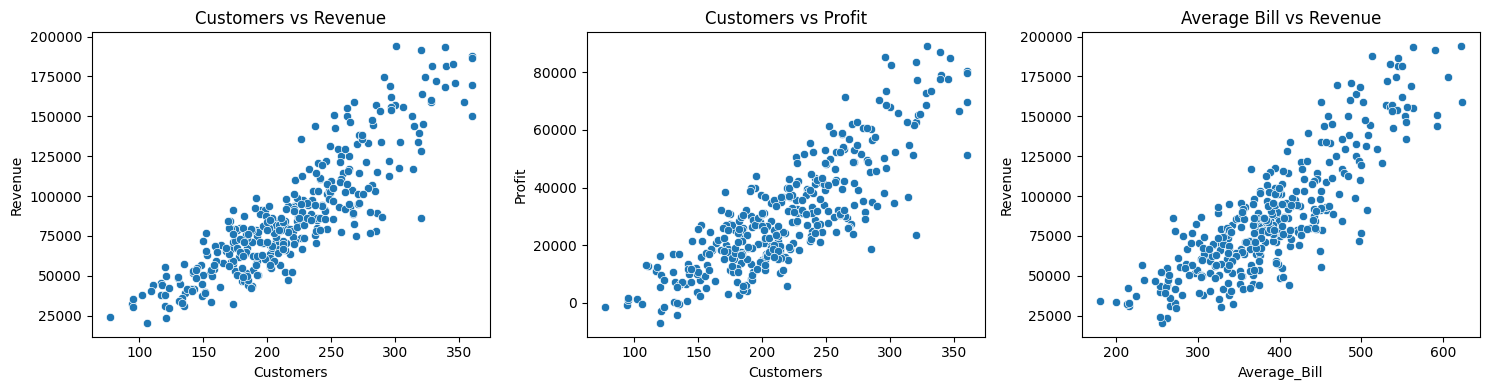

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=df, x="Customers", y="Revenue", ax=axes[0])
axes[0].set_title("Customers vs Revenue")

sns.scatterplot(data=df, x="Customers", y="Profit", ax=axes[1])
axes[1].set_title("Customers vs Profit")

sns.scatterplot(data=df, x="Average_Bill", y="Revenue", ax=axes[2])
axes[2].set_title("Average Bill vs Revenue")

plt.tight_layout()
plt.show()


## 11. Marketing Spend, Staff and Delivery Analysis

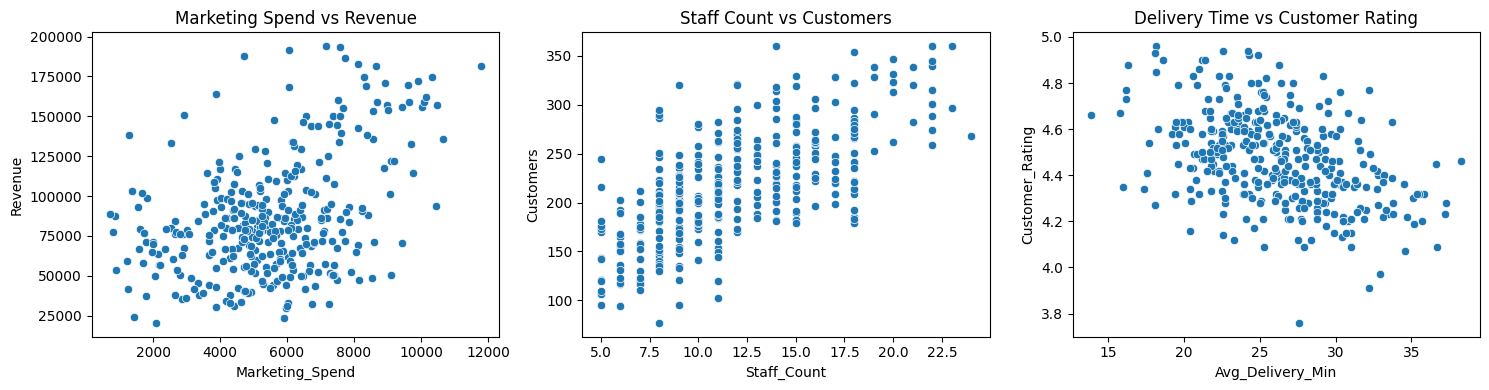

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=df, x="Marketing_Spend", y="Revenue", ax=axes[0])
axes[0].set_title("Marketing Spend vs Revenue")

sns.scatterplot(data=df, x="Staff_Count", y="Customers", ax=axes[1])
axes[1].set_title("Staff Count vs Customers")

sns.scatterplot(data=df, x="Avg_Delivery_Min", y="Customer_Rating", ax=axes[2])
axes[2].set_title("Delivery Time vs Customer Rating")

plt.tight_layout()
plt.show()


## 12. Correlation Analysis

In [17]:
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()

display(correlation_matrix.round(3))


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Staff_Count,1.00,0.28,0.69,0.67,0.52,0.69,0.68,0.79,0.56,-0.18,0.08,0.08,-0.02
Marketing_Spend,0.28,1.00,0.41,0.42,0.33,0.43,0.41,0.48,0.35,0.10,-0.06,0.06,-0.05
Customers,0.69,0.41,1.00,0.98,0.53,0.88,0.84,0.86,0.84,0.18,-0.05,0.00,-0.10
Orders,0.67,0.42,0.98,1.00,0.52,0.86,0.83,0.84,0.81,0.19,-0.05,0.02,-0.09
Average_Bill,0.52,0.33,0.53,0.52,1.00,0.84,0.84,0.80,0.83,-0.03,0.04,-0.05,-0.04
Revenue,0.69,0.43,0.88,0.86,0.84,1.00,0.98,0.96,0.97,0.08,0.01,-0.03,-0.09
Food_Cost,0.68,0.41,0.84,0.83,0.84,0.98,1.00,0.97,0.92,0.08,0.00,-0.03,-0.08
Operating_Cost,0.79,0.48,0.86,0.84,0.80,0.96,0.97,1.00,0.86,0.02,0.02,0.01,-0.07
Profit,0.56,0.35,0.84,0.81,0.83,0.97,0.92,0.86,1.00,0.13,-0.01,-0.06,-0.11
Avg_Delivery_Min,-0.18,0.10,0.18,0.19,-0.03,0.08,0.08,0.02,0.13,1.00,-0.44,0.01,-0.11


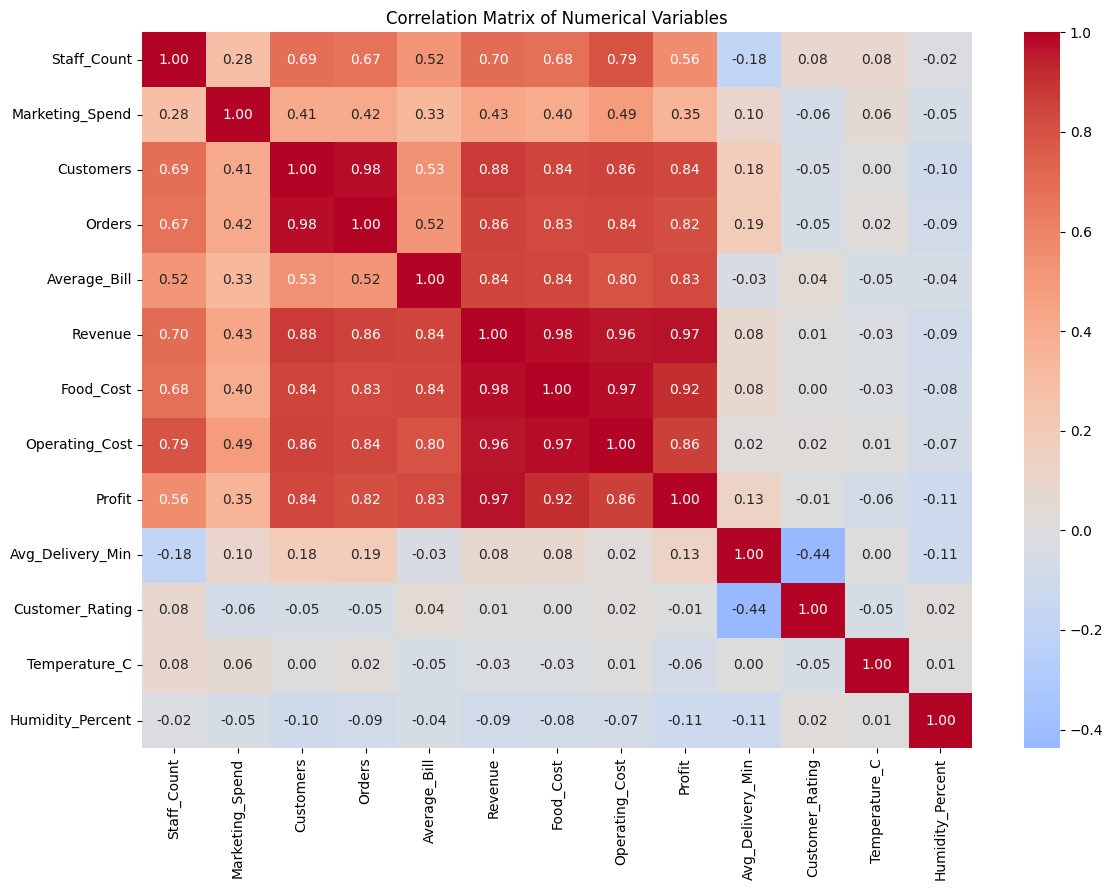

In [18]:
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


### Interpreting correlation

Correlation measures the strength and direction of a **linear relationship** between two numerical variables. Values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values near 0 indicate little linear relationship.

Correlation should not be interpreted as proof of causation.

In [19]:
# Display the strongest correlations with Profit, excluding Profit itself
profit_corr = correlation_matrix["Profit"].drop("Profit").sort_values(key=lambda s: s.abs(), ascending=False)
display(profit_corr.to_frame("Correlation_with_Profit"))


,Correlation_with_Profit
Revenue,0.97
Food_Cost,0.92
Operating_Cost,0.86
Customers,0.84
Average_Bill,0.83
Orders,0.82
Staff_Count,0.56
Marketing_Spend,0.35
Avg_Delivery_Min,0.13
Humidity_Percent,-0.11


## 13. Additional Descriptive Analysis

In [20]:
# Average performance by month
monthly = df.groupby("Month").agg(
    Customers=("Customers", "mean"),
    Revenue=("Revenue", "mean"),
    Profit=("Profit", "mean"),
    Rating=("Customer_Rating", "mean")
).sort_values("Profit", ascending=False)

display(monthly)

# Average performance by day
daily = df.groupby("Day").agg(
    Customers=("Customers", "mean"),
    Revenue=("Revenue", "mean"),
    Profit=("Profit", "mean"),
    Rating=("Customer_Rating", "mean")
).sort_values("Revenue", ascending=False)

display(daily)


,Customers,Revenue,Profit,Rating
Month,,,,
May,232.54,"97,688.38","35,697.50",4.46
March,216.19,"86,936.61","31,550.08",4.50
February,218.02,"87,147.27","30,256.80",4.44
April,219.12,"88,531.11","30,100.44",4.45
January,213.82,"84,384.44","29,012.63",4.48
June,207.90,"78,780.56","25,887.55",4.47


,Customers,Revenue,Profit,Rating
Day,,,,
Sunday,256.66,"101,835.93","38,698.20",4.43
Saturday,251.75,"99,643.14","37,695.28",4.47
Tuesday,202.50,"83,801.58","26,958.94",4.48
Thursday,206.85,"81,236.42","27,668.98",4.45
Wednesday,199.94,"80,674.05","26,807.62",4.44
Friday,200.72,"80,418.65","27,033.10",4.50
Monday,202.24,"79,398.29","26,416.72",4.49


## 14. Key Data-Driven Observations

1. **Customers and orders are extremely strongly related.** The correlation between Customers and Orders is approximately **0.98**, indicating that higher customer traffic is closely associated with more orders.

2. **Customer volume is a major business-performance indicator.** Customers have strong positive correlations with Revenue (**0.876**) and Profit (**0.836**), showing that records with higher customer traffic generally also report higher revenue and profit.

3. **Revenue is very strongly associated with Profit.** Revenue and Profit have a correlation of approximately **0.967**. This is consistent with the fact that profitable high-revenue records tend to occur together, although correlation alone does not establish causation.

4. **Srinagar is the strongest branch by total performance in this dataset.** It records the highest total revenue (about **₹45.11 lakh**) and the highest total profit (about **₹15.76 lakh**) among the eight branches.

5. **The South region has the highest aggregate revenue and profit.** South records about **₹1.21 crore revenue** and **₹42.05 lakh profit**, slightly ahead of North and clearly ahead of West. Differences should be interpreted alongside the number of records in each region.

6. **Standard stores contribute the largest total revenue and profit.** Standard stores generate about **₹1.71 crore revenue** and **₹60.04 lakh profit**. Premium stores have fewer records but show a relatively strong total profit contribution, while Express stores have the lowest total profit among the three store types.

7. **Delivery time is the clearest operational factor associated with customer ratings.** Average delivery time and customer rating have a moderate negative correlation of about **-0.437**, suggesting that longer delivery times tend to coincide with lower ratings.

8. **Marketing spend has a moderate positive relationship with business activity but not as strong as customer volume.** Marketing spend correlates with Revenue at about **0.431** and with Profit at about **0.350**. This suggests an association between higher marketing investment and stronger performance, but the relationship is considerably weaker than the relationships involving customers and revenue.

## 15. Conclusion

The EDA shows that **customer volume, orders, average bill, and revenue are the strongest business-performance variables** in the dataset. Revenue is closely linked to profit, while staffing is positively associated with customer volume and revenue. At the operational level, **delivery time has a meaningful negative association with customer ratings**, making delivery efficiency an important area to monitor.

Performance also varies across branches, regions, and store types. Srinagar leads the branches in aggregate revenue and profit, South leads the regions, and Standard stores contribute the largest overall totals. Marketing spend is positively associated with revenue and profit, but the relationship is weaker than the direct business-volume relationships.

Overall, the dataset suggests that management should monitor **customer traffic, order volume, revenue generation, staffing, marketing investment, and delivery efficiency together** rather than relying on a single performance metric.
